# 멕시코풍 프랜차이즈 chipotle 주문 데이터 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
chipo = pd.read_csv("./data/tsv/chipotle.tsv", sep="\t")

In [3]:
chipo.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


In [4]:
# 데이터의 행과 열 파악
chipo.shape

(4622, 5)

In [5]:
chipo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            4622 non-null   int64 
 1   quantity            4622 non-null   int64 
 2   item_name           4622 non-null   object
 3   choice_description  3376 non-null   object
 4   item_price          4622 non-null   object
dtypes: int64(2), object(3)
memory usage: 180.7+ KB


In [6]:
chipo.columns

Index(['order_id', 'quantity', 'item_name', 'choice_description',
       'item_price'],
      dtype='object')

- 피처의 의미
    - order_id : 주문 번호
    - quantity : 아이템의 주문 수량
    - item_name : 주문한 아이템의 이름
    - choice_description : 주문한 아이템의 상세 선택 옵션
    - item_price : 주문 아이템의 가격 정보

In [7]:
chipo.describe()

,order_id,quantity
count,4622.000000,4622.000000
mean,927.254868,1.075725
std,528.890796,0.410186
min,1.000000,1.000000
25%,477.250000,1.000000
50%,926.000000,1.000000
75%,1393.000000,1.000000
max,1834.000000,15.000000


- 간이분석 내용
    - 평균 주문 수량은 약 1.08개
        - 대부분 한 아이템은 하나의 주문
        - 한 사람이 같은 메뉴를 여러 개 구매하는 경우는 많지 않음
 
    - order_id는 숫자의 의미를 갖지 않기 때문에 str로 변환해야 할 수 있음
 
    - item_price는 수치적 특징을 파악해야 하는데 object 타입이기 때문에 수치형으로 변환해야 함
        - 데이터 전처리 필요

In [8]:
# 범주형 데이터의 데이터 종류 수 파악하기
print(chipo["order_id"].nunique())
print(chipo["item_name"].nunique())

1834
50


## 데이터 속성 탐색

### 가장 많이 주문한 아이템

In [10]:
# 아이템별 주문 횟수
chipo["item_name"].value_counts()[:10]

item_name
Chicken Bowl                    726
Chicken Burrito                 553
Chips and Guacamole             479
Steak Burrito                   368
Canned Soft Drink               301
Steak Bowl                      211
Chips                           211
Bottled Water                   162
Chicken Soft Tacos              115
Chips and Fresh Tomato Salsa    110
Name: count, dtype: int64

In [14]:
# 아이템별 주문 총량(판매량)
item_qt = chipo.groupby("item_name")["quantity"].sum()
item_qt.sort_values(ascending = False).head(10)

item_name
Chicken Bowl                    761
Chicken Burrito                 591
Chips and Guacamole             506
Steak Burrito                   386
Canned Soft Drink               351
Chips                           230
Steak Bowl                      221
Bottled Water                   211
Chips and Fresh Tomato Salsa    130
Canned Soda                     126
Name: quantity, dtype: int64

### 간이 시각화

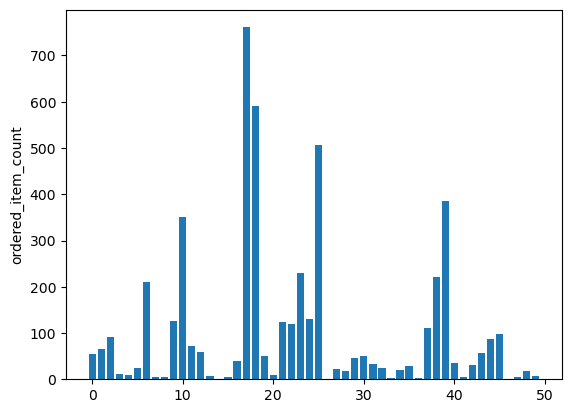

In [13]:
# item 수가 너무 많아서 시각화로 다 나타내기 힘들기 때문에 숫자로 표현
x_pos = np.arange(len(item_qt))

plt.bar(x_pos, item_qt)
plt.ylabel("ordered_item_count")

plt.show()

## 데이터 전처리

### item_price 피처 전처리

In [15]:
chipo["item_price"].head()

0     $2.39 
1     $3.39 
2     $3.39 
3     $2.39 
4    $16.98 
Name: item_price, dtype: object

- 원인
    - 가격을 나타내는 숫자 앞에 $ 기호가 붙어 있음
 
- 해결 방안
    - map과 lambda를 통해 float형으로 변환

In [18]:
chipo["item_price"] = chipo["item_price"].map(lambda x : float(x[1:]))

In [19]:
chipo.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98


In [20]:
chipo.dtypes

order_id                int64
quantity                int64
item_name              object
choice_description     object
item_price            float64
dtype: object

In [21]:
chipo.describe()

,order_id,quantity,item_price
count,4622.000000,4622.000000,4622.000000
mean,927.254868,1.075725,7.464336
std,528.890796,0.410186,4.245557
min,1.000000,1.000000,1.090000
25%,477.250000,1.000000,3.390000
50%,926.000000,1.000000,8.750000
75%,1393.000000,1.000000,9.250000
max,1834.000000,15.000000,44.250000


## 추가 데이터 탐색

### 주문 당 평균 계산 금액

In [24]:
chipo.groupby("order_id")["item_price"].sum().mean()

np.float64(18.811428571428568)

- 한 사람이 약 19달러 가량의 주문을 할 것으로 예상됨

### 한 주문에 20달러 이상 지불한 주문

1. order_id를 기준으로 그룹화
2. item_price의 합계를 기준으로 필터링

In [25]:
order_group = chipo.groupby("order_id").sum()
order_group.head()

,quantity,item_name,choice_description,item_price
order_id,,,,
1,4,Chips and Fresh Tomato SalsaIzzeNantucket Nect...,[Clementine][Apple],11.56
2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98
3,2,Chicken BowlSide of Chips,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",12.67
4,2,Steak BurritoSteak Soft Tacos,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",21.00
5,2,Steak BurritoChips and Guacamole,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",13.70


In [26]:
order_group[order_group["item_price"] >= 20]

,quantity,item_name,choice_description,item_price
order_id,,,,
4,2,Steak BurritoSteak Soft Tacos,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",21.00
18,4,Chicken Soft TacosChicken Soft TacosChips and ...,"[Roasted Chili Corn Salsa, Rice][Roasted Chili...",24.90
20,4,Chips and GuacamoleChicken BowlSteak BurritoCh...,"[Roasted Chili Corn Salsa, [Rice, Black Beans,...",36.20
21,3,Chicken BurritoSteak BurritoIzze,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",23.36
26,2,Barbacoa Soft TacosVeggie Burrito,"[Fresh Tomato Salsa, [Fajita Vegetables, Black...",20.50
...,...,...,...,...
1827,5,Chicken BowlChips and GuacamoleCanned Soft Dri...,"[Roasted Chili Corn Salsa, [Cheese, Lettuce]][...",32.95
1829,3,Steak BurritoVeggie BurritoCanned Soft Drink,"[Tomatillo Green Chili Salsa, [Rice, Cheese, S...",24.25
1830,2,Steak BurritoVeggie Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",23.00


In [27]:
order_group[order_group["item_price"] >= 20].shape

(589, 4)

### 각 아이템의 가격 구하기

- 현재 아이템 데이터는 없기 때문에 아이템의 가격을 구하기 위해서는 주문 데이터에서 유추하는 방법 밖에 없음

1. 동일한 아이템을 1개만 구매한 주문을 선별
2. item_name을 기준으로 그룹화 한 뒤 각 그룹별 최저가를 계산

In [28]:
# 동일한 아이템을 1개만 구매한 주문을 선별
one_item = chipo[chipo["quantity"] == 1]

In [29]:
one_item.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",10.98


In [30]:
# item_name을 기준으로 그룹화 한 뒤 각 그룹별 최저가를 계산
item_price = one_item.groupby("item_name").min()
item_price.head()

,order_id,quantity,choice_description,item_price
item_name,,,,
6 Pack Soft Drink,129,1,[Coke],6.49
Barbacoa Bowl,19,1,"[Fresh Tomato (Mild), [Lettuce, Black Beans, R...",8.69
Barbacoa Burrito,11,1,"[Fresh Tomato (Mild), [Black Beans, Rice, Sour...",8.69
Barbacoa Crispy Tacos,75,1,"[Fresh Tomato Salsa, Guacamole]",8.99
Barbacoa Salad Bowl,501,1,"[Fresh Tomato Salsa, Guacamole]",9.39


In [31]:
# 정렬
item_price.sort_values("item_price", ascending = False)

,order_id,quantity,choice_description,item_price
item_name,,,,
Steak Salad Bowl,250,1,"[Fresh Tomato Salsa, Lettuce]",9.39
Barbacoa Salad Bowl,501,1,"[Fresh Tomato Salsa, Guacamole]",9.39
Carnitas Salad Bowl,468,1,"[Fresh Tomato Salsa, [Rice, Black Beans, Chees...",9.39
Carnitas Soft Tacos,103,1,"[Fresh Tomato Salsa (Mild), [Black Beans, Rice...",8.99
Carnitas Crispy Tacos,230,1,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",8.99
Steak Soft Tacos,4,1,"[Fresh Tomato Salsa (Mild), [Cheese, Sour Cream]]",8.99
Carnitas Salad,1500,1,"[[Fresh Tomato Salsa (Mild), Roasted Chili Cor...",8.99
Carnitas Bowl,17,1,"[Fresh Tomato (Mild), [Guacamole, Lettuce, Ric...",8.99
Barbacoa Soft Tacos,26,1,"[Fresh Tomato Salsa, [Black Beans, Cheese, Let...",8.99


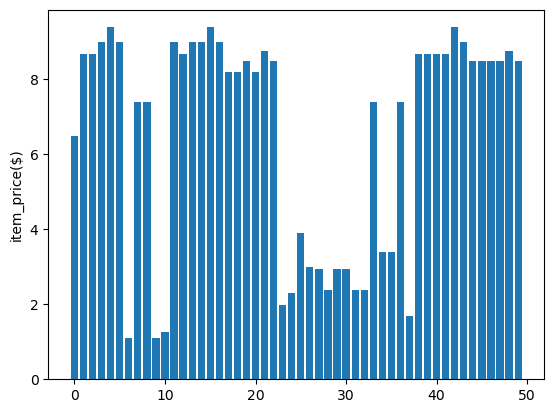

In [32]:
# 아이템 가격 시각화
x_pos = np.arange(len(item_price))

plt.bar(x_pos, item_price["item_price"])
plt.ylabel("item_price($)")

plt.show()

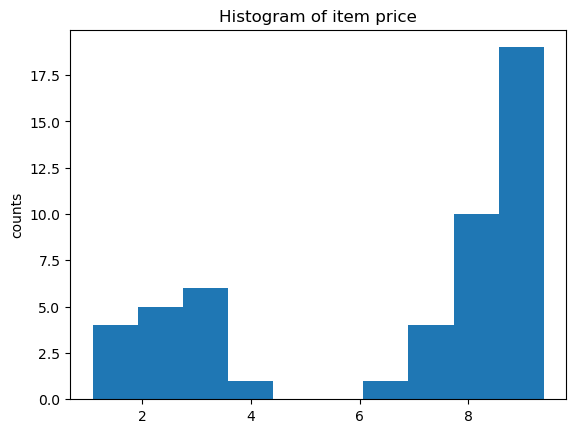

In [33]:
# 아이템 가격 히스토그램
plt.hist(item_price["item_price"])

plt.ylabel("counts")
plt.title("Histogram of item price")

plt.show()

### 가장 비싼 주문은 총 몇 개의 아이템을 주문했는 지 파악

In [34]:
chipo.groupby("order_id").sum().sort_values("item_price", ascending = False).head()

,quantity,item_name,choice_description,item_price
order_id,,,,
926,23,Steak BurritoChicken BowlChicken BowlChicken B...,"[Fresh Tomato Salsa, [Rice, Sour Cream, Lettuc...",205.25
1443,35,Chips and Fresh Tomato SalsaBottled Water6 Pac...,"[Coke][Fresh Tomato Salsa, [Fajita Vegetables,...",160.74
1483,14,Chicken BowlSteak BowlChicken BurritoSteak Bow...,"[Roasted Chili Corn Salsa, [Rice, Black Beans,...",139.00
691,11,Chicken BurritoChicken Salad BowlSteak Burrito...,"[Tomatillo Red Chili Salsa, [Rice, Cheese, Sou...",118.25
1786,20,Chicken BowlCarnitas BurritoChicken BowlChicke...,"[Fresh Tomato Salsa, Rice][Fresh Tomato Salsa,...",114.30


### Chicken Bowl을 2개 이상 주문한 고객들의 Chicken Bowl 메뉴에 대한 총 주문 수량 구하기

In [35]:
chicken_df = chipo[chipo["item_name"] == "Chicken Bowl"]

In [36]:
chicken_df.head()

,order_id,quantity,item_name,choice_description,item_price
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",10.98
13,7,1,Chicken Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",11.25
19,10,1,Chicken Bowl,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",8.75
26,13,1,Chicken Bowl,"[Roasted Chili Corn Salsa (Medium), [Pinto Bea...",8.49


In [37]:
group_chicken = chicken_df.groupby("order_id")["quantity"].sum()

In [38]:
group_chicken.head()

order_id
2     2
3     1
7     1
10    1
13    1
Name: quantity, dtype: int64

In [39]:
result = group_chicken[group_chicken >= 2]

In [40]:
result.head()

order_id
2      2
34     2
70     2
93     2
124    3
Name: quantity, dtype: int64

In [41]:
result.sum()

np.int64(260)